
Explaining for class: setosa


Sampling hypothesis space: 100%|██████████| 500/500 [00:00<00:00, 587.97it/s]


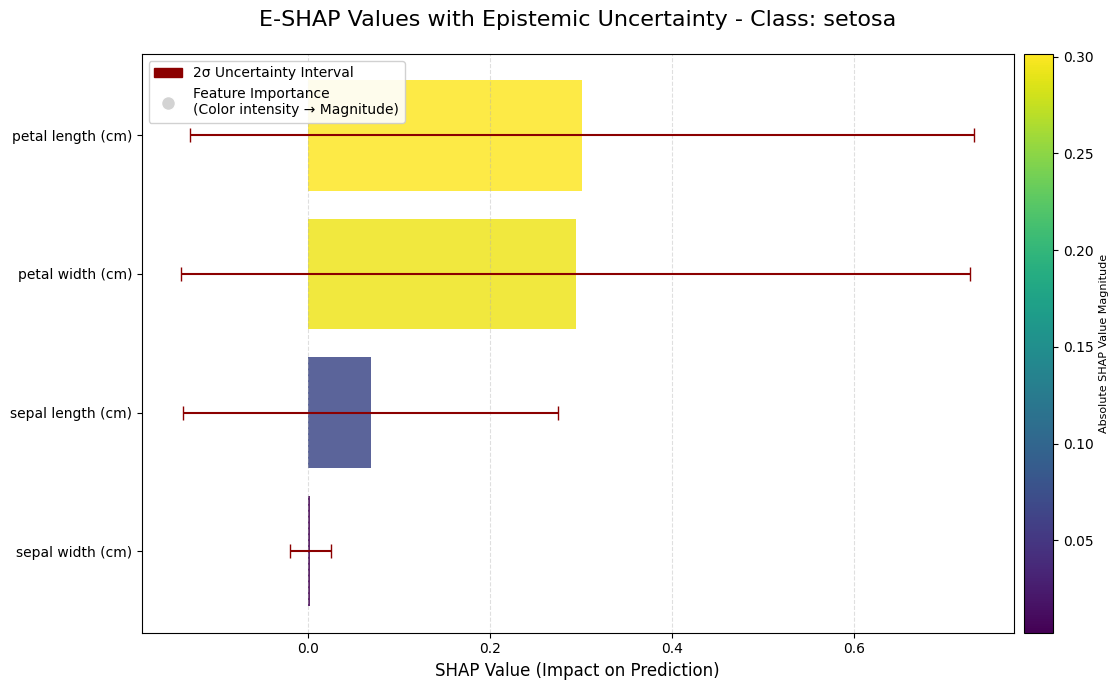

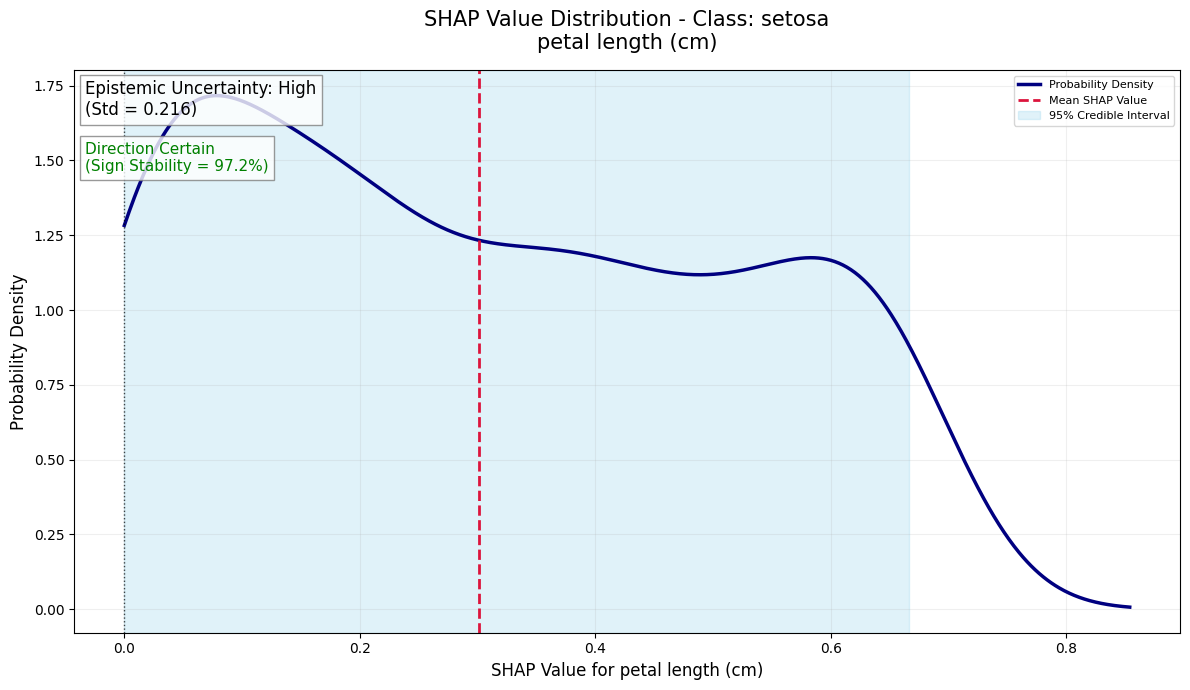

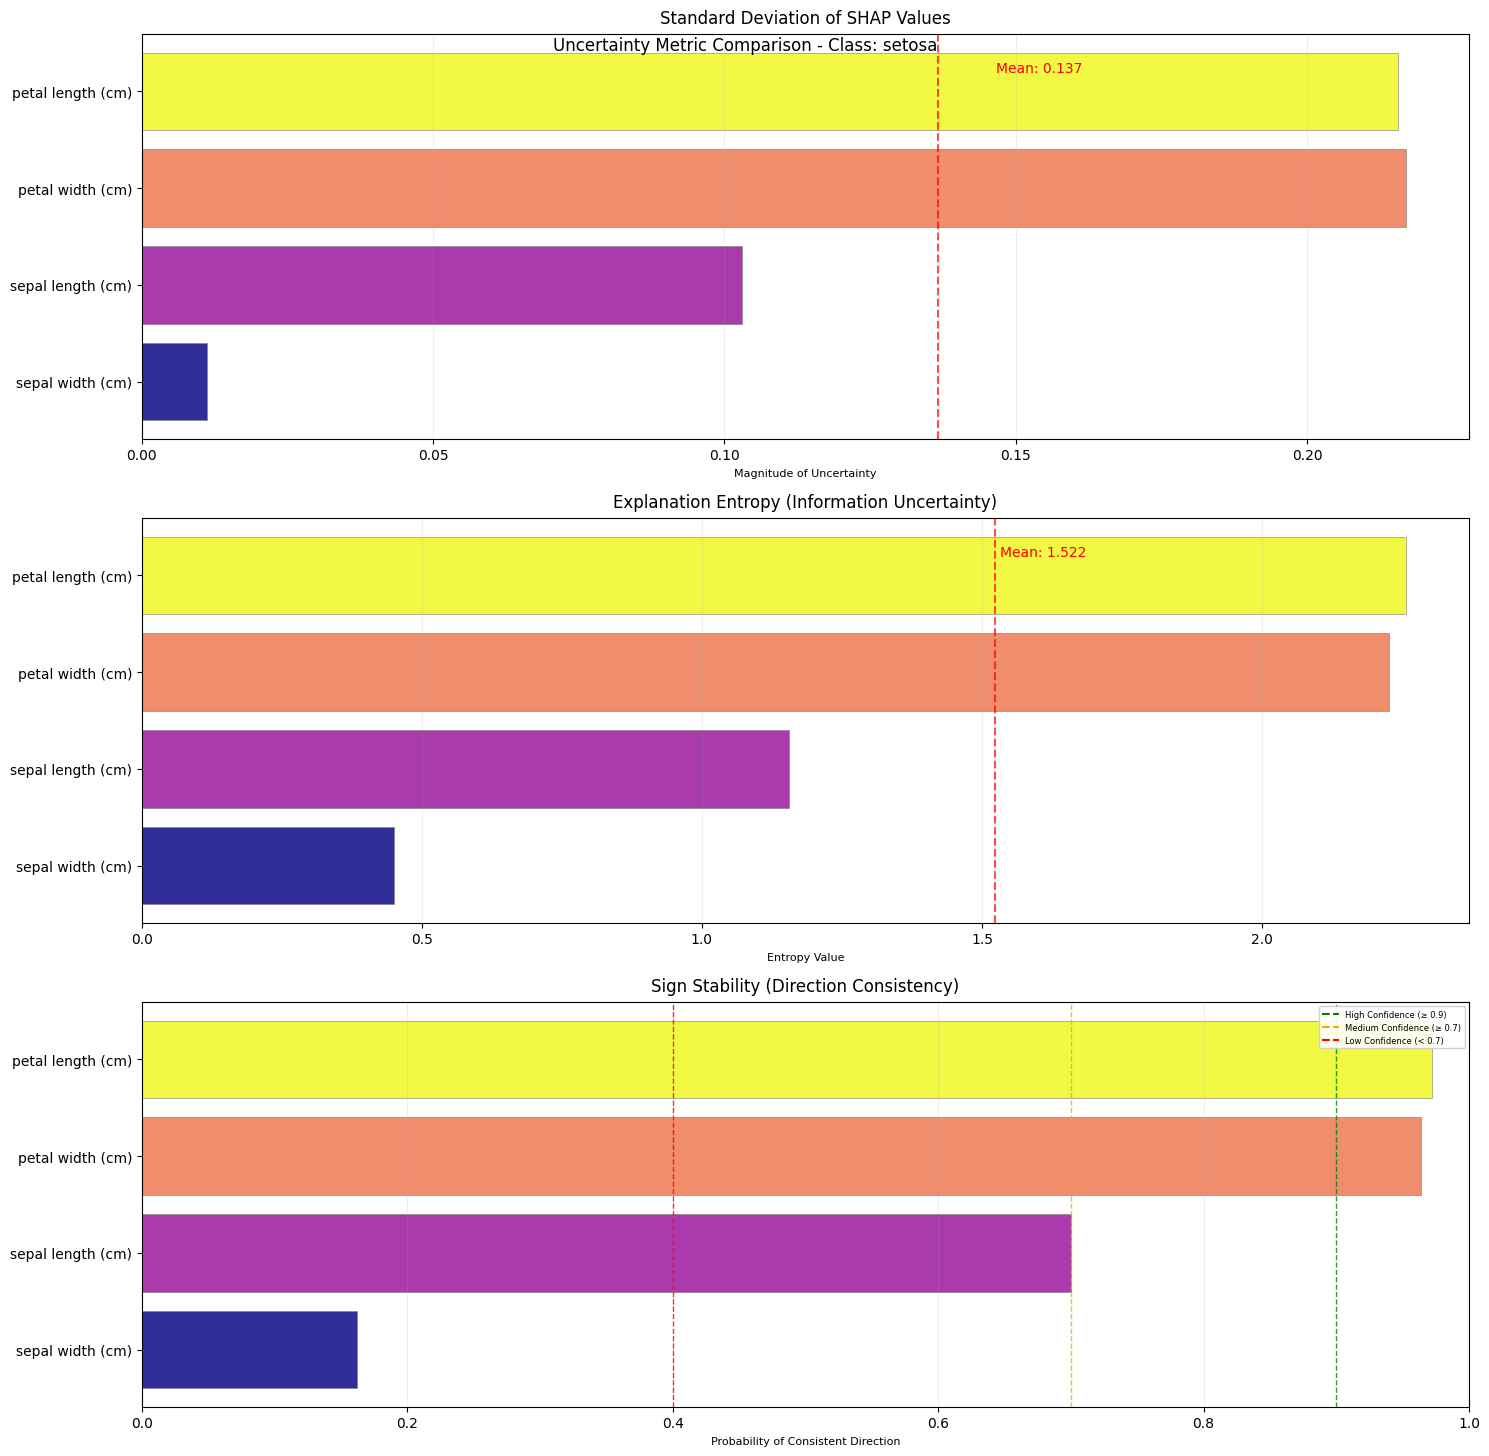


Explaining for class: versicolor


Sampling hypothesis space: 100%|██████████| 500/500 [00:00<00:00, 600.91it/s]


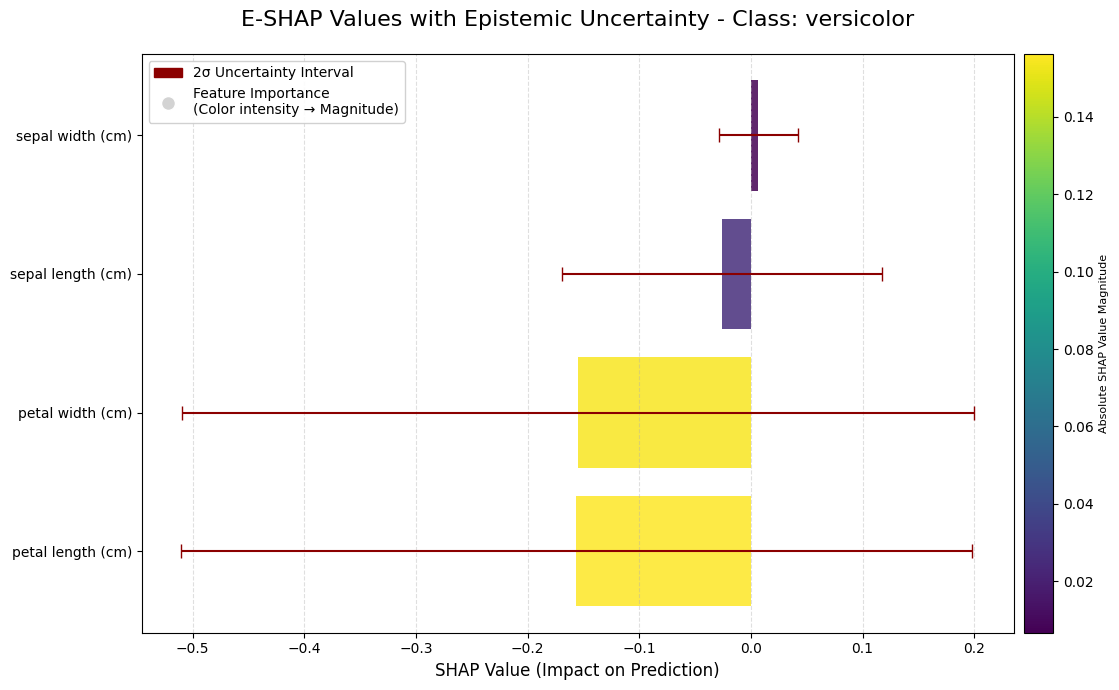

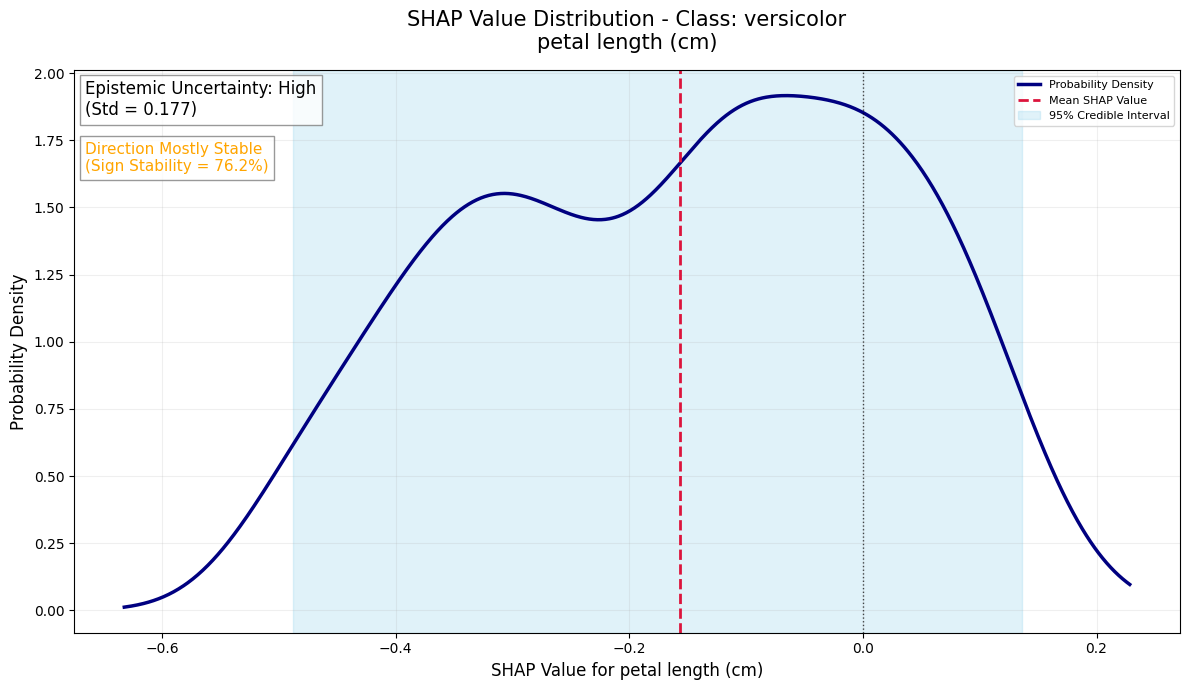

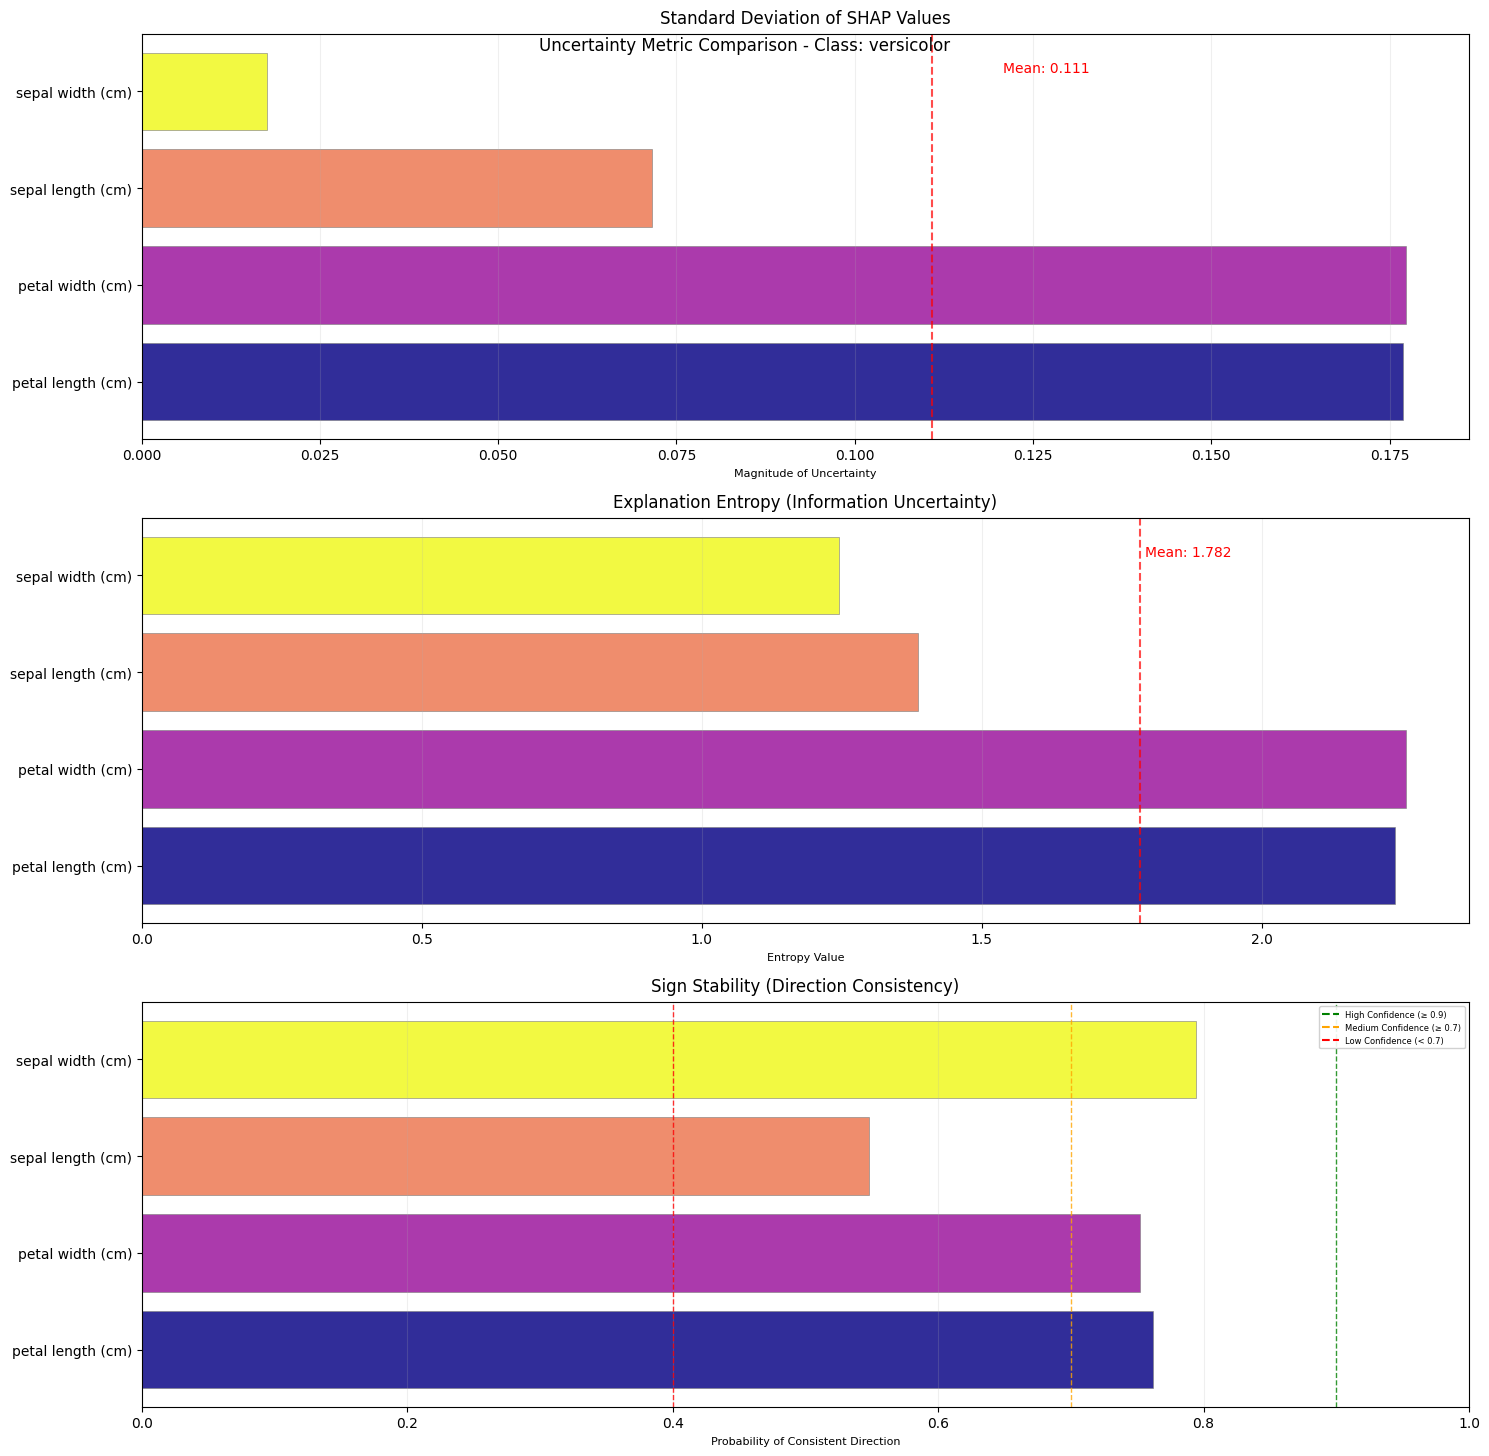


Explaining for class: virginica


Sampling hypothesis space: 100%|██████████| 500/500 [00:00<00:00, 590.16it/s]


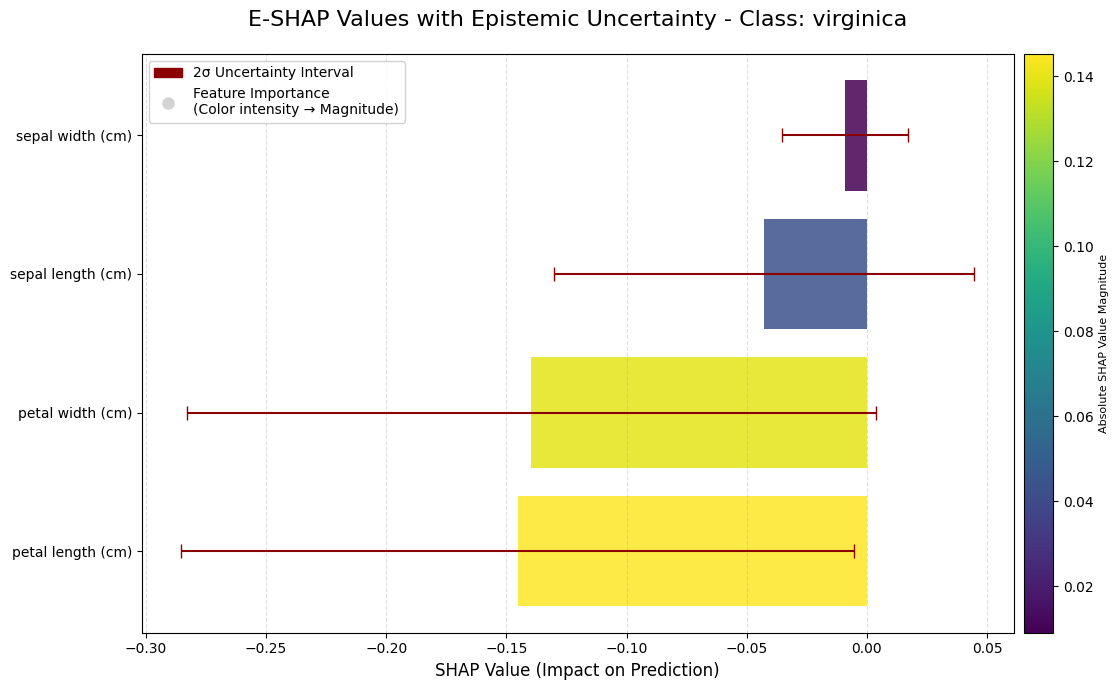

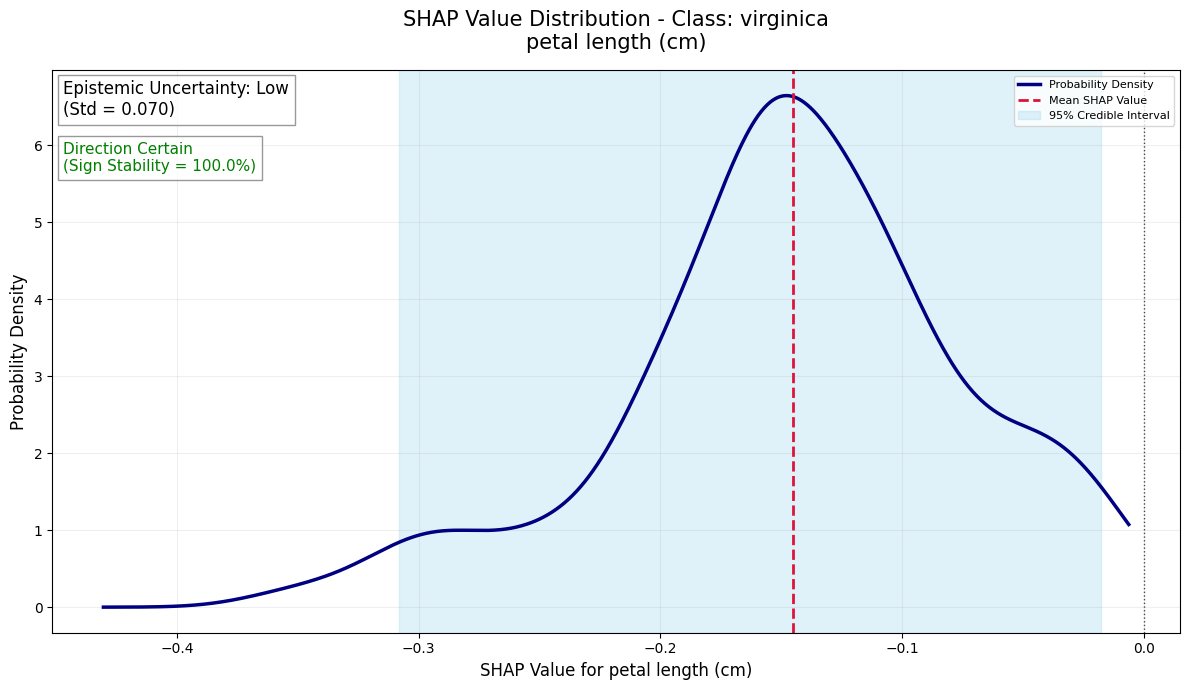

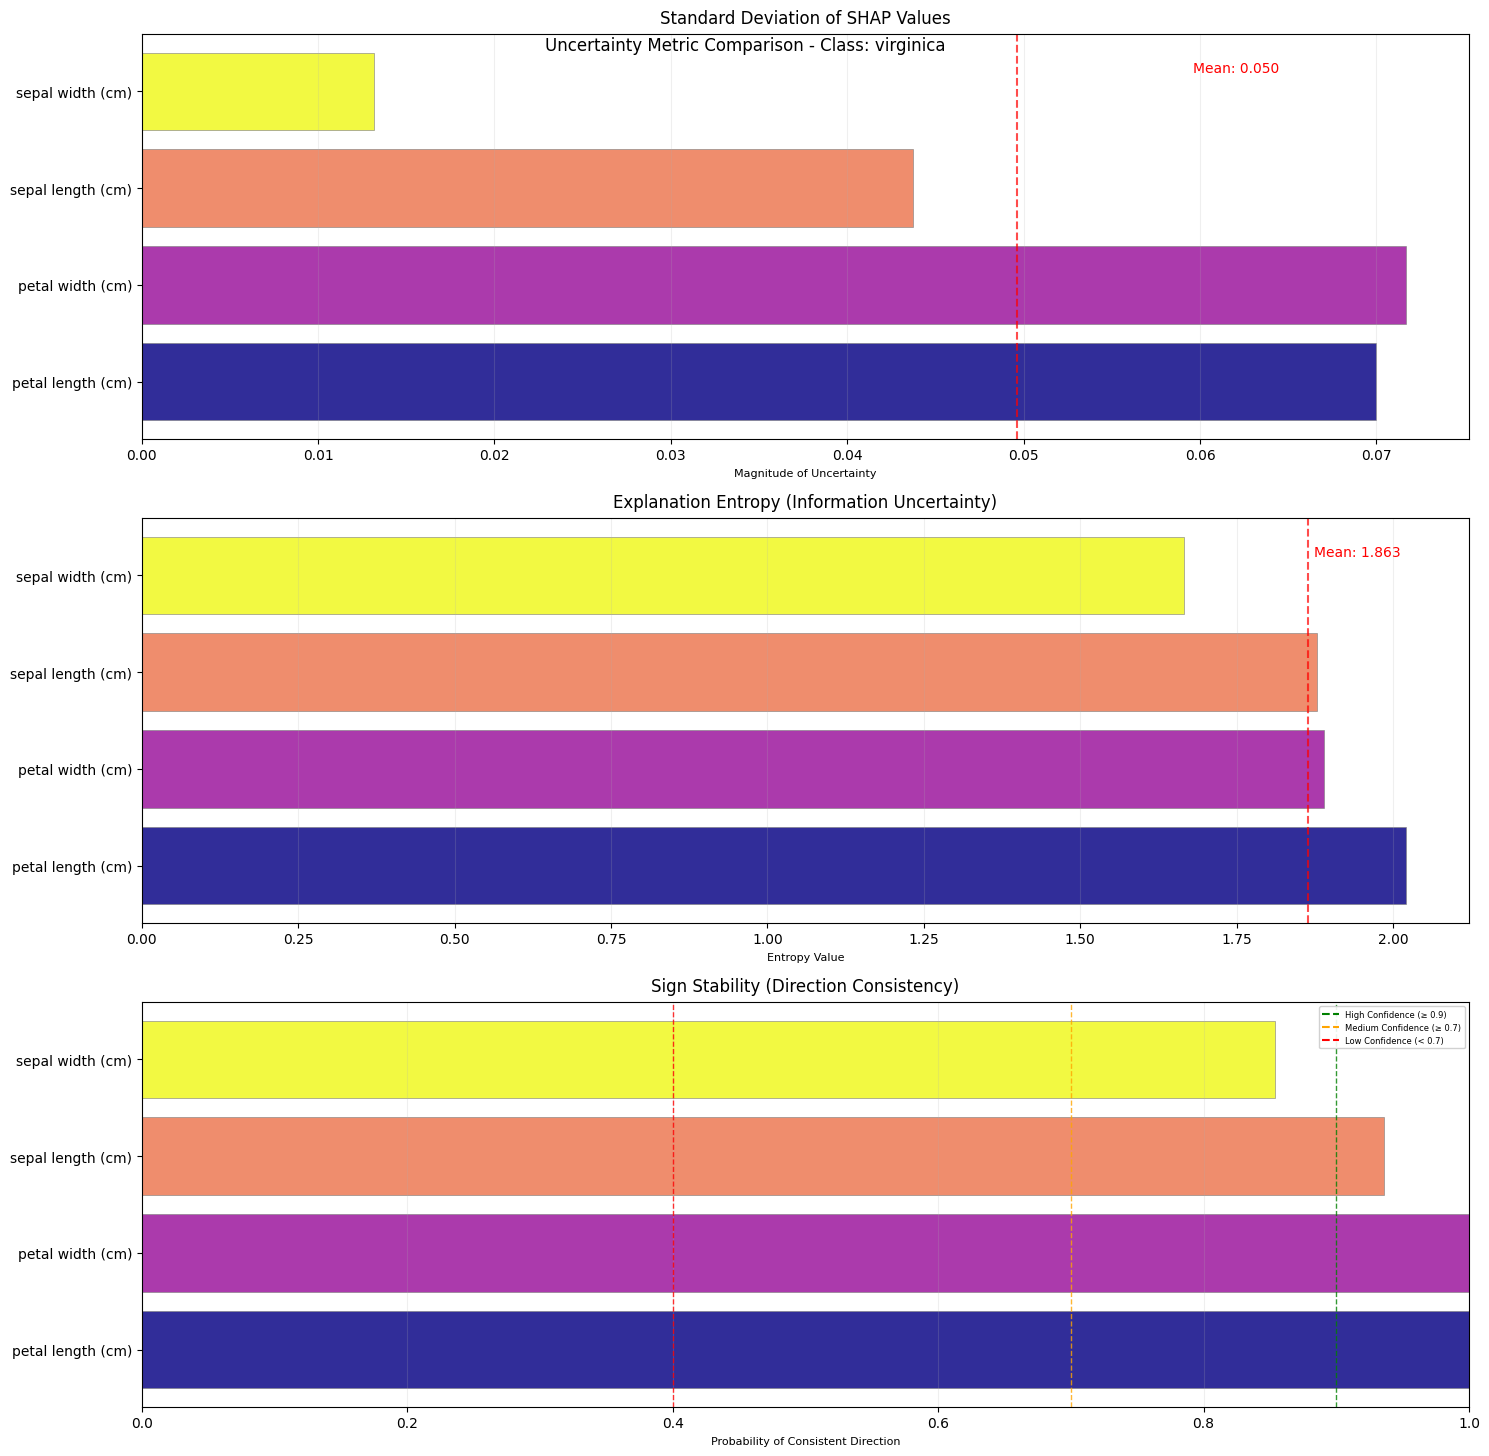

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
import shap
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

class ESHAPExplainer:
    def __init__(self, model, X_train, y_train, beta=5.0, random_state=None):
        """
        Initialize E-SHAP explainer for classification models
        
        Args:
            model: Trained tree ensemble classifier (RandomForest, XGBoost, etc.)
            X_train: Training features
            y_train: Training labels
            beta: Temperature parameter for softmax weighting
            random_state: Random seed
        """
        if not hasattr(model, 'classes_'):
            raise ValueError("Model must be a classifier with 'classes_' attribute")
            
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.beta = beta
        self.random_state = random_state
        self.weights_ = self._compute_tree_weights()
        self.full_explainer = shap.TreeExplainer(model)
        self.classes_ = model.classes_
        
    def _compute_tree_weights(self):
        """Compute tree weights based on performance"""
        if hasattr(self.model, 'estimators_'):
            scores = []
            for tree in self.model.estimators_:
                pred = tree.predict(self.X_train)
                score = accuracy_score(self.y_train, pred)
                scores.append(score)
            
            # Softmax weighting with temperature control
            max_score = np.max(scores)
            exp_vals = np.exp(self.beta * (np.array(scores) - max_score))
            return exp_vals / np.sum(exp_vals)
        else:
            # Single tree model
            return np.array([1.0])
    
    def explain(self, x, n_samples=500, alpha=1.0, class_idx=None):
        """
        Compute E-SHAP values with uncertainty quantification for classification
        
        Args:
            x: Input instance to explain
            n_samples: Number of hypothesis samples
            alpha: Dirichlet concentration parameter
            class_idx: Which class to explain (default: first class)
            
        Returns:
            Dictionary with SHAP distributions and uncertainty metrics
        """
        np.random.seed(self.random_state)
        
        # Determine number of trees and features
        n_trees = len(self.model.estimators_) if hasattr(self.model, 'estimators_') else 1
        n_features = x.shape[1]
        phi_dist = np.zeros((n_samples, n_features))
        
        # Default to first class if not specified
        if class_idx is None:
            class_idx = 0

        for s in tqdm(range(n_samples), desc="Sampling hypothesis space"):
            # Dirichlet-weighted tree sampling
            dirichlet_weights = np.random.dirichlet(alpha * self.weights_)
            tree_indices = np.random.choice(
                n_trees, 
                size=n_trees, 
                p=dirichlet_weights
            )
            
            # Create sub-ensemble with sampled trees
            if hasattr(self.model, 'estimators_'):
                sub_ensemble = [self.model.estimators_[i] for i in tree_indices]
                temp_model = clone(self.model)
                temp_model.estimators_ = sub_ensemble
            else:
                temp_model = self.model  # Single tree model
                
            # Compute SHAP values using __call__ for consistent output format
            explainer = shap.TreeExplainer(temp_model)
            shap_output = explainer(x)  # Returns Explanation object
            
            # Extract SHAP values - shape (1, n_features, n_classes)
            shap_values = shap_output.values
            phi = shap_values[0, :, class_idx]  # Get values for specific class
            phi_dist[s] = phi
        
        # Compute uncertainty metrics
        results = {
            "mean": np.mean(phi_dist, axis=0),
            "std": np.std(phi_dist, axis=0),
            "ci_95": np.percentile(phi_dist, [2.5, 97.5], axis=0),
            "entropy": self._compute_entropy(phi_dist),
            "sign_stability": self._compute_sign_stability(phi_dist),
            "samples": phi_dist
        }
        return results
    
    def _compute_entropy(self, phi_dist):
        """Compute explanation entropy for each feature"""
        entropies = []
        for i in range(phi_dist.shape[1]):
            hist, bin_edges = np.histogram(phi_dist[:, i], bins=10, density=True)
            bin_probs = hist * np.diff(bin_edges)
            entropies.append(entropy(bin_probs))
        return np.array(entropies)
    
    def _compute_sign_stability(self, phi_dist):
        """Compute sign stability for each feature"""
        mean_sign = np.sign(np.mean(phi_dist, axis=0))
        stability = np.mean(np.sign(phi_dist) == mean_sign[np.newaxis, :], axis=0)
        return stability    
    
    def plot_uncertainty_bars(self, result, feature_names, title="E-SHAP Values with Epistemic Uncertainty", class_name=None):
        """
        Plot SHAP values with uncertainty bars
        
        Args:
            class_name: Name of the class being explained
        """
        plt.figure(figsize=(12, 7))
        if class_name:
            title = f"{title} - Class: {class_name}"
            
        order = np.argsort(result['mean'])
        y_pos = np.arange(len(feature_names))
        
        # Calculate absolute SHAP for color coding
        abs_mean = np.abs(result['mean'])
        norm = plt.Normalize(abs_mean.min(), abs_mean.max())
        colors = plt.cm.viridis(norm(abs_mean[order]))
        
        # Create plot with error bars
        plt.barh(
            y_pos, 
            result['mean'][order],
            xerr=2*result['std'][order],
            capsize=5,
            alpha=0.85,
            color=colors,
            ecolor='darkred'
        )
        
        plt.yticks(y_pos, [feature_names[i] for i in order])
        plt.xlabel('SHAP Value (Impact on Prediction)', fontsize=12)
        plt.title(title, fontsize=16, pad=20)
        plt.grid(axis='x', linestyle='--', alpha=0.4)
        
        # Create comprehensive legend
        legend_elements = [
            mpatches.Patch(color='darkred', label='2σ Uncertainty Interval'),
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor='lightgray', markersize=10, 
                   label='Feature Importance\n(Color intensity → Magnitude)'),
        ]
        
        plt.legend(
            handles=legend_elements, 
            loc='upper left',
            frameon=True,
            framealpha=0.9,
            fontsize=10
        )
        
        # Add colorbar for SHAP magnitude
        sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01)
        cbar.set_label('Absolute SHAP Value Magnitude', fontsize=8)
        plt.tight_layout()
        plt.show()

    def plot_uncertainty_distribution(self, result, feature_names, feature_idx, 
                                      title="SHAP Value Distribution", class_name=None):
        """
        Plot kernel density estimate with enhanced annotations
        
        Args:
            class_name: Name of the class being explained
        """
        plt.figure(figsize=(12, 7))
        if class_name:
            title = f"{title} - Class: {class_name}"
            
        samples = result['samples'][:, feature_idx]
        
        # Kernel density estimation
        kde = gaussian_kde(samples)
        x = np.linspace(min(samples)*1.2, max(samples)*1.2, 1000)
        plt.plot(x, kde(x), lw=2.5, color='navy', label='Probability Density')
        
        # Uncertainty metrics
        mean_val = result['mean'][feature_idx]
        ci_low, ci_high = result['ci_95'][:, feature_idx]
        std_val = result['std'][feature_idx]
        
        plt.axvline(mean_val, color='crimson', linestyle='--', lw=2, label='Mean SHAP Value')
        plt.axvspan(
            ci_low,
            ci_high,
            alpha=0.25, 
            color='skyblue',
            label='95% Credible Interval'
        )
        
        # Add distribution characteristics
        plt.axvline(0, color='black', linestyle=':', alpha=0.7, lw=1)
        plt.text(
            0.01, 0.92, 
            f"Epistemic Uncertainty: High\n(Std = {std_val:.3f})" if std_val > 0.15 else f"Epistemic Uncertainty: Low\n(Std = {std_val:.3f})",
            transform=plt.gca().transAxes,
            fontsize=12,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
        )
        
        # Add sign stability indicator
        sign_stab = result['sign_stability'][feature_idx]
        stability_text = "Direction Certain" if sign_stab > 0.9 else "Direction Uncertain" if sign_stab < 0.7 else "Direction Mostly Stable"
        plt.text(
            0.01, 0.82, 
            f"{stability_text}\n(Sign Stability = {sign_stab:.1%})",
            transform=plt.gca().transAxes,
            fontsize=11,
            color='green' if sign_stab > 0.9 else 'red' if sign_stab < 0.7 else 'orange',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
        )
        
        plt.xlabel(f'SHAP Value for {feature_names[feature_idx]}', fontsize=12)
        plt.ylabel('Probability Density', fontsize=12)
        plt.title(f"{title}\n{feature_names[feature_idx]}", fontsize=15, pad=15)
        plt.legend(loc='upper right', fontsize=8)
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
    
    def plot_uncertainty_comparison(self, result, feature_names, title="Uncertainty Metric Comparison", class_name=None):
        """
        Enhanced comparison plot with unified color scheme
        
        Args:
            class_name: Name of the class being explained
        """
        if class_name:
            title = f"{title} - Class: {class_name}"
            
        fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharey=True)
        plt.suptitle(title, fontsize=12, y=0.95)
        
        # Sort by SHAP magnitude
        order = np.argsort(result['mean'])
        sorted_features = [feature_names[i] for i in order]
        
        # Create consistent color mapping
        colors = plt.cm.plasma(np.linspace(0, 1, len(feature_names)))
        
        # Standard Deviation plot
        axes[0].barh(
            sorted_features,
            result['std'][order],
            color=colors,
            alpha=0.85,
            edgecolor='gray',
            linewidth=0.5
        )
        axes[0].set_title('Standard Deviation of SHAP Values', fontsize=12, pad=8)
        axes[0].set_xlabel('Magnitude of Uncertainty', fontsize=8)
        axes[0].axvline(np.mean(result['std']), color='red', linestyle='--', alpha=0.7)
        axes[0].text(
            np.mean(result['std']) + 0.01, len(feature_names)*0.8, 
            f'Mean: {np.mean(result["std"]):.3f}',
            color='red',
            fontsize=10
        )
        axes[0].grid(axis='x', alpha=0.2)
        
        # Entropy plot
        axes[1].barh(
            sorted_features,
            result['entropy'][order],
            color=colors,
            alpha=0.85,
            edgecolor='gray',
            linewidth=0.5
        )
        axes[1].set_title('Explanation Entropy (Information Uncertainty)', fontsize=12, pad=8)
        axes[1].set_xlabel('Entropy Value', fontsize=8)
        axes[1].axvline(np.mean(result['entropy']), color='red', linestyle='--', alpha=0.7)
        axes[1].text(
            np.mean(result['entropy']) + 0.01, len(feature_names)*0.8, 
            f'Mean: {np.mean(result["entropy"]):.3f}',
            color='red',
            fontsize=10
        )
        axes[1].grid(axis='x', alpha=0.2)
        
        # Sign Stability plot
        axes[2].barh(
            sorted_features,
            result['sign_stability'][order],
            color=colors,
            alpha=0.85,
            edgecolor='gray',
            linewidth=0.5
        )
        axes[2].set_title('Sign Stability (Direction Consistency)', fontsize=12, pad=8)
        axes[2].set_xlabel('Probability of Consistent Direction', fontsize=8)
        axes[2].set_xlim(0, 1)
        axes[2].grid(axis='x', alpha=0.2)

        # Vertical dashed lines
        axes[2].axvline(0.9, color='green', linestyle='--', linewidth=1, alpha=0.8)
        axes[2].axvline(0.7, color='orange', linestyle='--', linewidth=1, alpha=0.8)
        axes[2].axvline(0.4, color='red', linestyle='--', linewidth=1, alpha=0.8)

        # Create proxy legend handles
        legend_lines = [
            mlines.Line2D([], [], color='green', linestyle='--', label='High Confidence (≥ 0.9)'),
            mlines.Line2D([], [], color='orange', linestyle='--', label='Medium Confidence (≥ 0.7)'),
            mlines.Line2D([], [], color='red', linestyle='--', label='Low Confidence (< 0.7)')
        ]
        axes[2].legend(handles=legend_lines, loc='upper right', fontsize=6, frameon=True, framealpha=0.9)

        plt.tight_layout()
        plt.show()


# Example usage with Iris dataset and RandomForestClassifier
if __name__ == "__main__":
    from sklearn.datasets import load_iris
    from sklearn.ensemble import RandomForestClassifier
    
    # Load and prepare data
    iris = load_iris()
    X = iris.data
    y = iris.target
    feature_names = iris.feature_names
    class_names = iris.target_names
    
    # Train classifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    # Create explainer
    explainer = ESHAPExplainer(rf, X, y, beta=5.0, random_state=42)
    
    # Explain first instance for each class
    instance = X[0:1]
    
    for class_idx, class_name in enumerate(class_names):
        print(f"\nExplaining for class: {class_name}")
        results = explainer.explain(instance, class_idx=class_idx)
        
        # Plot results
        explainer.plot_uncertainty_bars(
            results, 
            feature_names,
            class_name=class_name
        )
        
        # Plot distribution for most important feature
        most_important_feature = np.argmax(np.abs(results['mean']))
        explainer.plot_uncertainty_distribution(
            results,
            feature_names,
            most_important_feature,
            class_name=class_name
        )
        
        explainer.plot_uncertainty_comparison(
            results,
            feature_names,
            class_name=class_name
        )